# Residue Theorem: Integral Around a Circle

Consider the function

$$f(z)=\frac{1}{z^2+1}$$

and the positively oriented contour

$$C: |z-i|=\frac12.$$

This notebook uses SymPy for symbolic analysis, SciPy for independent numerical integration, and Matplotlib for visualization.

## The Residue Theorem in Simple Terms

If a function has isolated poles inside a closed contour $C$ and is analytic on the contour itself, then the contour integral depends only on the poles inside it:

$$\oint_C f(z)\,dz = 2\pi i\sum_{z_k\,\text{inside }C}\operatorname{Res}(f,z_k).$$

A residue is the coefficient of $1/(z-z_k)$ in the expansion of a function near a pole $z_k$. Thus, a complicated integral over an entire curve can be replaced by computing a few local coefficients. Positive orientation means moving counterclockwise.

## Import Libraries and Set Up the Problem

For numerical integration of the complex integral, SciPy will be applied separately to the real and imaginary parts.

In [12]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad

z = sp.symbols("z")
f_sym = 1 / (z**2 + 1)

center = 1j
radius = 0.5
t_start, t_end = 0.0, 2 * np.pi

print("f(z) =", f_sym)
print("Contour: |z - i| =", radius)

f(z) = 1/(z**2 + 1)
Contour: |z - i| = 0.5


## Poles and Residues with SymPy

The poles are obtained from the equation $z^2+1=0$. We then compute the residue at each pole.

In [13]:
poles = sp.solve(sp.denom(f_sym), z)
residues = {pole: sp.simplify(sp.residue(f_sym, z, pole)) for pole in poles}

print("Poles:", poles)
for pole, residue in residues.items():
    print(f"z = {pole}: residue = {residue}")

Poles: [-I, I]
z = -I: residue = I/2
z = I: residue = -I/2


## Which Poles Are Inside the Contour?

We check the condition $|z_k-i|<1/2$. The pole $z=i$ is the center of the circle and is inside, while the pole $z=-i$ is at distance $2$ from the center and is outside.

In [14]:
poles_complex = [complex(sp.N(pole)) for pole in poles]
inside_poles = [
    pole for pole in poles_complex
    if abs(pole - center) < radius
]

for pole in poles_complex:
    distance = abs(pole - center)
    location = "inside" if distance < radius else "outside"
    print(f"Pole {pole}: distance {distance:.3f}, {location} the contour")

assert len(inside_poles) == 1
assert np.isclose(inside_poles[0], 1j)

Pole -1j: distance 2.000, outside the contour
Pole 1j: distance 0.000, inside the contour


## Analytical Integral Using the Residue Theorem

We sum only the residues of the poles inside $C$ and multiply their sum by $2\pi i$.

In [15]:
inside_residue = sum(
    residues[pole] for pole in poles
    if abs(complex(sp.N(pole)) - center) < radius
)
integral_exact_sym = sp.simplify(2 * sp.pi * sp.I * inside_residue)
integral_exact = complex(sp.N(integral_exact_sym))

print("Sum of residues inside the contour =", inside_residue)
print("Analytical integral =", integral_exact_sym)
assert sp.simplify(integral_exact_sym - sp.pi) == 0

Sum of residues inside the contour = -I/2
Analytical integral = pi


## Independent Numerical Integration

Use the parameterization

$$z(t)=i+\frac12e^{it},\qquad \frac{dz}{dt}=\frac{i}{2}e^{it},\qquad 0\le t\le2\pi.$$

Then $\oint_C f(z)\,dz=\int_0^{2\pi} f(z(t))z\prime(t)\,dt$. The factor $dz/dt$ is essential: without it, the expression is not a contour integral.

In [16]:
def z_of_t(t):
    return center + radius * np.exp(1j * t)

def dz_dt(t):
    return 1j * radius * np.exp(1j * t)

def f_numeric(z_value):
    return 1 / (z_value**2 + 1)

def integrand(t):
    return f_numeric(z_of_t(t)) * dz_dt(t)

real_part, real_error = quad(lambda t: integrand(t).real, t_start, t_end, epsabs=1e-12, epsrel=1e-12)
imag_part, imag_error = quad(lambda t: integrand(t).imag, t_start, t_end, epsabs=1e-12, epsrel=1e-12)
integral_numeric = real_part + 1j * imag_part

print("Numerical integral =", integral_numeric)
print("SciPy error estimates: real = %.2e, imag = %.2e" % (real_error, imag_error))

Numerical integral = (3.1415926535897927-3.731001930026964e-17j)
SciPy error estimates: real = 3.49e-14, imag = 5.64e-15


## Contour and Poles in the Complex Plane

The plot marks the pole $i$ inside the contour and the pole $-i$ outside. Points on the circle are generated with increasing $t$, so the traversal is counterclockwise.

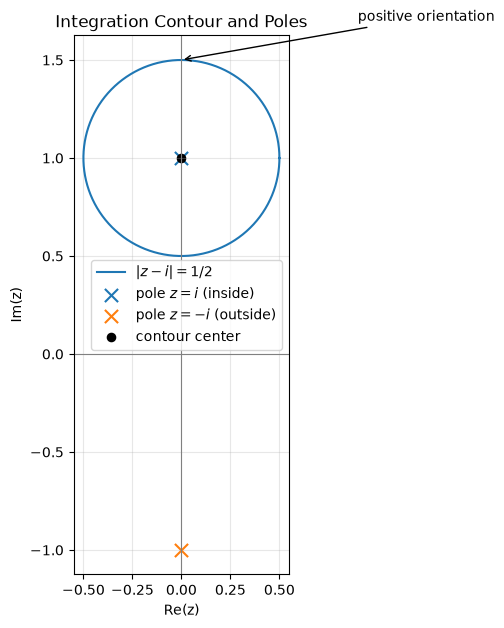

In [17]:
theta = np.linspace(0, 2 * np.pi, 500)
contour = z_of_t(theta)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(contour.real, contour.imag, label=r"$|z-i|=1/2$")
ax.scatter([1j.real], [1j.imag], s=90, marker="x", label=r"pole $z=i$ (inside)")
ax.scatter([(-1j).real], [(-1j).imag], s=90, marker="x", label=r"pole $z=-i$ (outside)")
ax.scatter([center.real], [center.imag], s=35, color="black", label="contour center")
ax.annotate("positive orientation", xy=(contour[125].real, contour[125].imag),
            xytext=(0.9, 1.7), arrowprops={"arrowstyle": "->"})
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title("Integration Contour and Poles")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Comparison of Results and Absolute Error

In [18]:
absolute_error = abs(integral_numeric - integral_exact)

print(f"Analytical result: {integral_exact:.15g}")
print(f"Numerical result:    {integral_numeric:.15g}")
print(f"Absolute error:      {absolute_error:.3e}")

assert absolute_error < 1e-10
print("Check passed: the results agree to high precision.")

Analytical result: 3.14159265358979+0j
Numerical result:    3.14159265358979-3.73100193002696e-17j
Absolute error:      4.457e-16
Check passed: the results agree to high precision.


## Experiment Series: Different Contours and Winding Numbers

The following five contours are considered for $f(z)=1/(z^2+1)$. In every case, the poles $z=i$ and $z=-i$ stay strictly off the contour. The numerical integral is computed independently from the parameterization, while the theoretical value is computed from the sum of residues multiplied by the winding number.

When both poles are inside, their residues sum to zero:

$$\operatorname{Res}(f,i)=-\frac{1}{2i},\qquad \operatorname{Res}(f,-i)=\frac{1}{2i},\qquad -\frac{1}{2i}+\frac{1}{2i}=0.$$

This is also consistent with the fact that the sum of all residues of a rational function, including the residue at infinity, is zero. Here $f(z)$ decays as $1/z^2$, so its residue at infinity is zero.


In [ ]:

# Shared functions for independent numerical and theoretical calculations
import pandas as pd

residue_values = {
    complex(sp.N(pole)): complex(sp.N(residue))
    for pole, residue in residues.items()
}


def numerical_contour_integral(contour_center, contour_radius, winding_number):
    def contour_z(t):
        return contour_center + contour_radius * np.exp(1j * winding_number * t)

    def contour_dz_dt(t):
        return 1j * winding_number * contour_radius * np.exp(1j * winding_number * t)

    def contour_integrand(t):
        return f_numeric(contour_z(t)) * contour_dz_dt(t)

    real_part = quad(
        lambda t: contour_integrand(t).real,
        0.0,
        2 * np.pi,
        epsabs=1e-11,
        epsrel=1e-11,
    )[0]
    imaginary_part = quad(
        lambda t: contour_integrand(t).imag,
        0.0,
        2 * np.pi,
        epsabs=1e-11,
        epsrel=1e-11,
    )[0]
    return real_part + 1j * imaginary_part


def residue_theorem_integral(contour_center, contour_radius, winding_number):
    enclosed_residues = [
        residue
        for pole, residue in residue_values.items()
        if abs(pole - contour_center) < contour_radius
    ]
    return 2 * np.pi * 1j * winding_number * sum(enclosed_residues)


cases = [
    {
        "case": "1. No poles inside",
        "center": 0.0 + 0.0j,
        "radius": 0.5,
        "winding": 1,
    },
    {
        "case": "2. One pole inside",
        "center": 1.0j,
        "radius": 0.5,
        "winding": 1,
    },
    {
        "case": "3. Both poles inside",
        "center": 0.0 + 0.0j,
        "radius": 2.0,
        "winding": 1,
    },
    {
        "case": "4. Clockwise traversal",
        "center": 1.0j,
        "radius": 0.5,
        "winding": -1,
    },
    {
        "case": "5. Two counterclockwise traversals",
        "center": 1.0j,
        "radius": 0.5,
        "winding": 2,
    },
]

results = []
for case in cases:
    distances = {
        pole: abs(pole - case["center"])
        for pole in poles_complex
    }
    assert all(
        not np.isclose(distance, case["radius"])
        for distance in distances.values()
    ), "A pole lies on the contour"

    enclosed_poles = [
        pole
        for pole, distance in distances.items()
        if distance < case["radius"]
    ]
    numerical_value = numerical_contour_integral(
        case["center"], case["radius"], case["winding"]
    )
    residue_value = residue_theorem_integral(
        case["center"], case["radius"], case["winding"]
    )
    results.append(
        {
            "Case": case["case"],
            "Numerical integral": numerical_value,
            "Via residues": residue_value,
            "Absolute error": abs(numerical_value - residue_value),
            "Poles inside": ", ".join(str(pole) for pole in enclosed_poles) or "none",
        }
    )

results_table = pd.DataFrame(results)
print(results_table.to_string(index=False))
assert results_table["Absolute error"].max() < 1e-9


                              Case          Numerical integral        Via residues  Absolute error Poles inside
                1. No poles inside -1.188482e-16-1.415005e-16j  0.000000+0.000000j    1.847899e-16         none
                2. One pole inside  3.141593e+00-3.731002e-17j  3.141593+0.000000j    4.456537e-16           1j
              3. Both poles inside  6.943233e-18-9.537539e-17j  0.000000+0.000000j    9.562779e-17      -1j, 1j
            4. Clockwise traversal -3.141593e+00+3.188357e-17j -3.141593+0.000000j    4.452323e-16           1j
5. Two counterclockwise traversals  6.283185e+00+3.065110e-17j  6.283185+0.000000j    3.065110e-17           1j


## Visualization of the Five Contours

Each plot shows both poles. Poles inside the corresponding contour are red; external poles are gray. The arrow indicates the traversal direction.


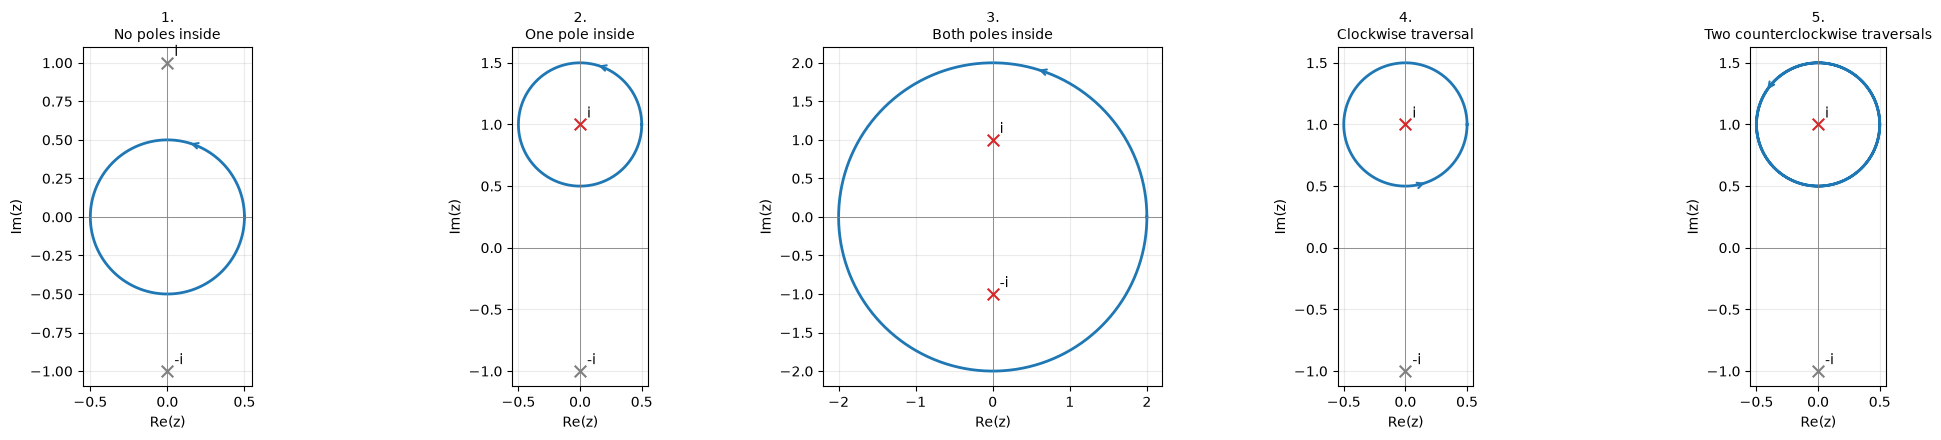

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(21, 4.5))

for axis, case in zip(axes, cases):
    theta = np.linspace(0.0, 2.0 * np.pi, 600)
    contour = case["center"] + case["radius"] * np.exp(1j * case["winding"] * theta)
    distances = {
        pole: abs(pole - case["center"])
        for pole in poles_complex
    }

    axis.plot(contour.real, contour.imag, color="tab:blue", lw=2)
    for pole, distance in distances.items():
        is_inside = distance < case["radius"]
        axis.scatter(
            pole.real,
            pole.imag,
            color="tab:red" if is_inside else "gray",
            marker="x",
            s=70,
            zorder=3,
        )
        axis.annotate(
            "i" if pole == 1j else "-i",
            (pole.real, pole.imag),
            xytext=(5, 5),
            textcoords="offset points",
        )

    arrow_index = 120
    next_index = arrow_index + (1 if case["winding"] > 0 else -1)
    axis.annotate(
        "",
        xy=(contour[next_index].real, contour[next_index].imag),
        xytext=(contour[arrow_index].real, contour[arrow_index].imag),
        arrowprops={"arrowstyle": "->", "color": "tab:blue", "lw": 1.5},
    )
    axis.axhline(0, color="gray", lw=0.6)
    axis.axvline(0, color="gray", lw=0.6)
    axis.set_title(case["case"].replace(". ", ".\n", 1), fontsize=10)
    axis.set_xlabel("Re(z)")
    axis.set_ylabel("Im(z)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()


## Interpretation of the Results

1. **No poles inside:** both computations give $0$, with an error of order $10^{-16}$.
2. **One pole inside:** the integral is $\pi$; the numerical result agrees with $2\pi i\operatorname{Res}(f,i)$.
3. **Both poles inside:** the integral is again $0$, because the residues $i/2$ and $-i/2$ cancel each other.
4. **Clockwise traversal:** reversing the orientation changes the sign, so the result is $-\pi$.
5. **Two counterclockwise traversals:** the winding number is $2$, so the result is $2\pi$.

For the completed numerical integration, the absolute error is below $10^{-15}$ in every case.
